# глава 3
## задание 3.1


В данном упражнении исследуется чирп-сигнал — синусоида с
изменяющейся во времени частотой. Рассматриваются два типа чирпа: линейный
(частота возрастает равномерно) и экспоненциальный

In [11]:
import matplotlib.pyplot as plt

from thinkdsp import Chirp, ExpoChirp

start_freq = 220
end_freq = 880
duration = 2.0

linear_chirp = Chirp(start=start_freq, end=end_freq)
exp_chirp = ExpoChirp(start=start_freq, end=end_freq)

wave_linear = linear_chirp.make_wave(duration=duration)
wave_exp = exp_chirp.make_wave(duration=duration)

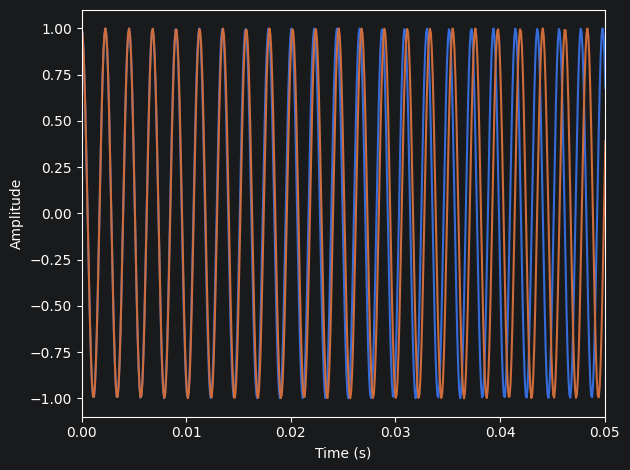

In [27]:


chirp = Chirp(start=440, end=880)
chirpexp = ExpoChirp(start=440, end=880)

wave_linear = chirp.make_wave(duration= 0.5)
wave_exp = chirpexp.make_wave(duration= 0.5)

wave_linear.plot()
wave_exp.plot()

decorate(xlabel='Time (s)', ylabel='Amplitude', xlim=(0, 0.05))

## Спектрограммы

In [34]:
chirp = Chirp(start=440, end=880)
chirpexp = ExpoChirp(start=440, end=880)

wave_linear = chirp.make_wave(duration=2)
wave_exp = chirpexp.make_wave(duration=2)

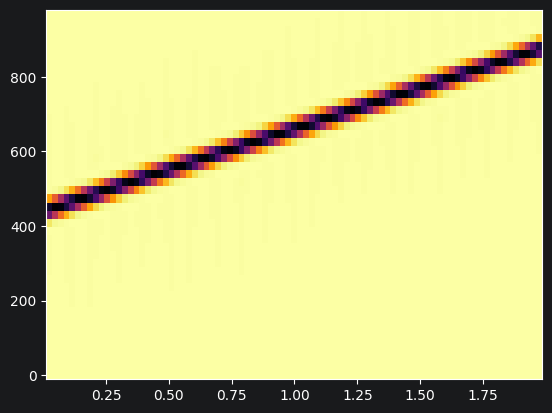

In [35]:
spec_linear = wave_linear.make_spectrogram(seg_length=512)
spec_linear.plot(high=1000)

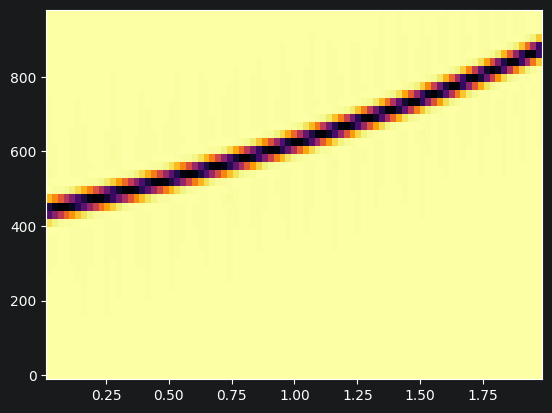

In [36]:
spec_exp = wave_exp.make_spectrogram(seg_length=512)
spec_exp.plot(high=1000)

## Задание 3.2

In [21]:
from thinkdsp import Chirp, normalize, unbias, PI2


class SawtoothChirp(Chirp):

    def evaluate(self, ts):
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / PI2
        frac, _ = np.modf(cycles)
        ys =  normalize(unbias(frac), self.amp)
        return ys


signal = SawtoothChirp(start=220, end=880)
wave = signal.make_wave(duration=1, framerate=4000)
wave.apodize()
wave.make_audio()

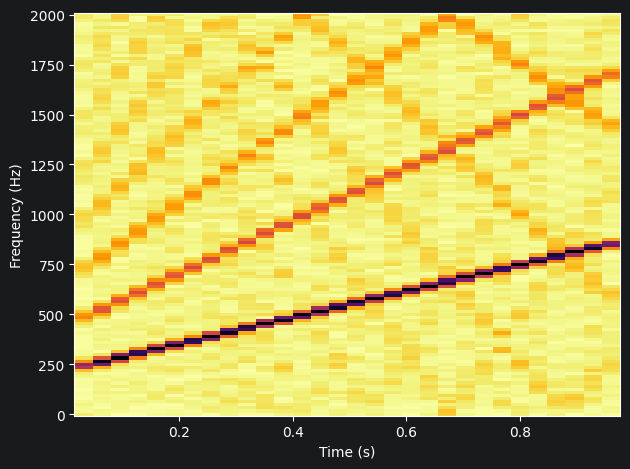

In [22]:


sp = wave.make_spectrogram(256)
sp.plot()
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')



## Задание 3.3

In [23]:
signal = SawtoothChirp(start=2500, end=3000)
wave = signal.make_wave(duration=1, framerate=20000)
wave.make_audio()

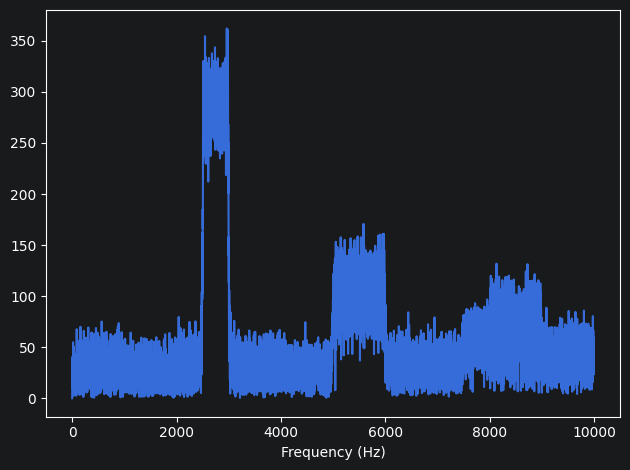

In [37]:
wave.make_spectrum().plot()
decorate(xlabel='Frequency (Hz)')

## Задание 3.4


In [42]:
from thinkdsp import read_wave

wave = read_wave('../180929__docquesting__crowd-noise.wav')
wave.make_audio()

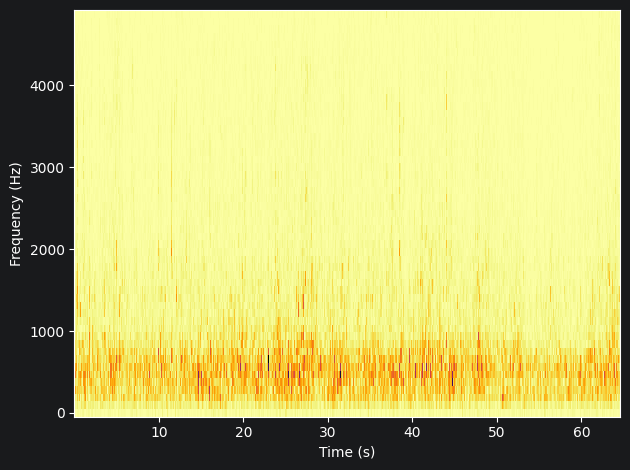

In [43]:
wave.make_spectrogram(512).plot(high=5000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

## Задание 3.5

In [44]:
class TromboneGliss(Chirp):

    def evaluate(self, ts):
        l1, l2 = 1.0 / self.start, 1.0 / self.end
        lengths = np.linspace(l1, l2, len(ts))
        freqs = 1 / lengths

        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        ys = self.amp * np.cos(phases)
        return ys



In [45]:
low = 262
high = 349
signal = TromboneGliss(high, low)
wave1 = signal.make_wave(duration=1)
wave1.apodize()
wave1.make_audio()

In [46]:
signal = TromboneGliss(low, high)
wave2 = signal.make_wave(duration=1)
wave2.apodize()
wave2.make_audio()

In [47]:
wave = wave1 | wave2
wave.make_audio()

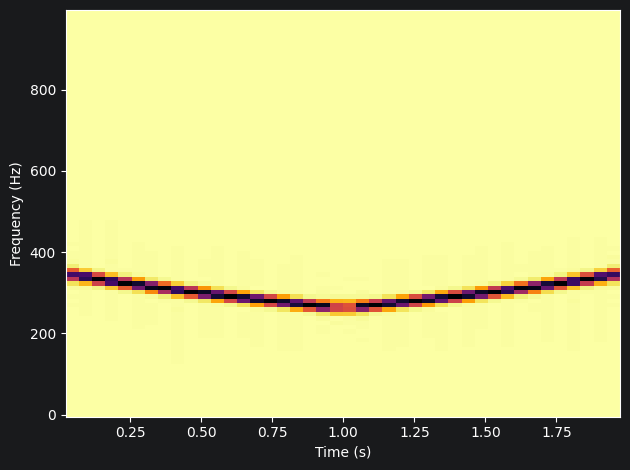

In [48]:
sp = wave.make_spectrogram(1024)
sp.plot(high=1000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

## Задание 3.6

In [59]:
import os
if not os.path.exists('../87778__marcgascon7__vocals.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/87778__marcgascon7__vocals.wav

In [60]:
wave = read_wave('../87778__marcgascon7__vocals.wav')
wave.make_audio()

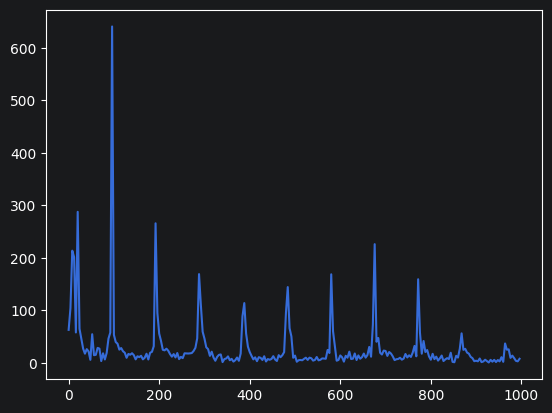

In [61]:
high = 1000

segment = wave.segment(start=1, duration=0.25)
segment.make_spectrum().plot(high=high)

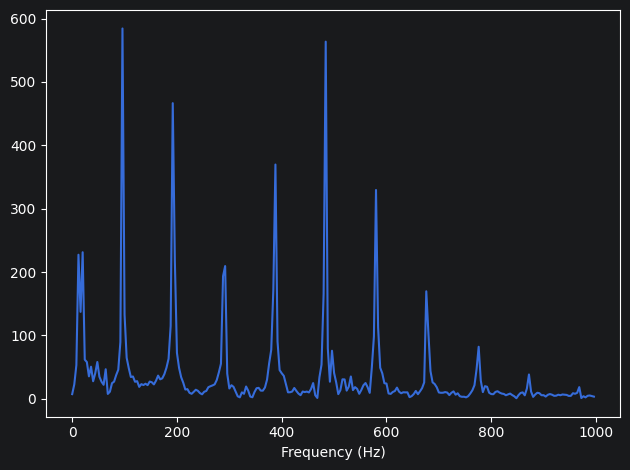

In [62]:
segment = wave.segment(start=2.2, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Frequency (Hz)')

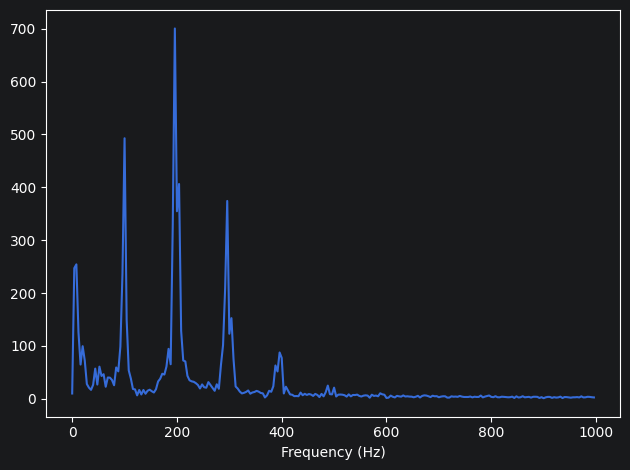

In [63]:
segment = wave.segment(start=3.5, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Frequency (Hz)')

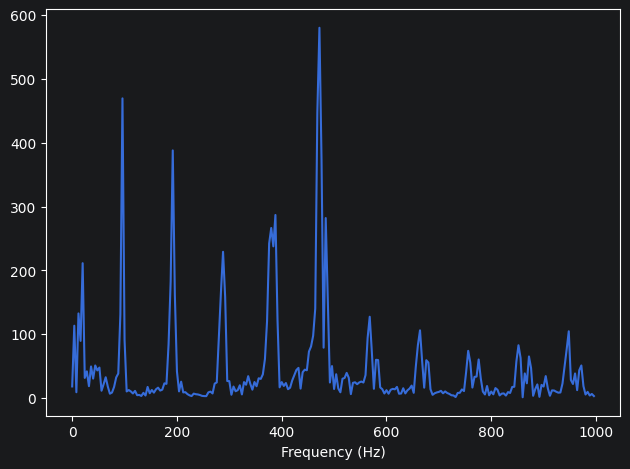

In [64]:
segment = wave.segment(start=5.1, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Frequency (Hz)')

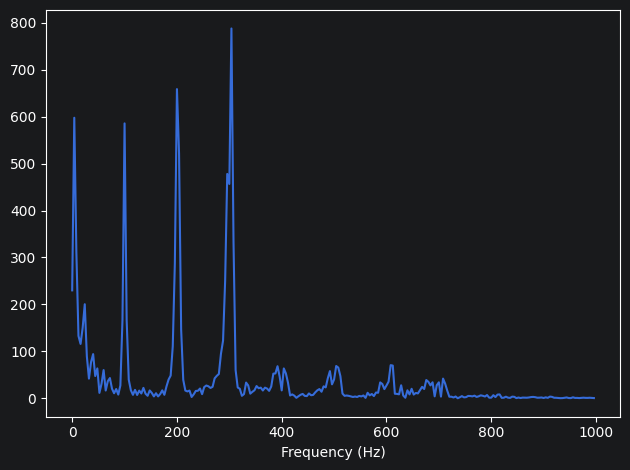

In [67]:
segment = wave.segment(start=6.5, duration=0.25)
segment.make_spectrum().plot(high=high)
decorate(xlabel='Frequency (Hz)')